In [50]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-5.0,5.0,100)
y=np.sqrt(10**2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [51]:
x1=np.linspace(-5.0,5.0,100)
y1=np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

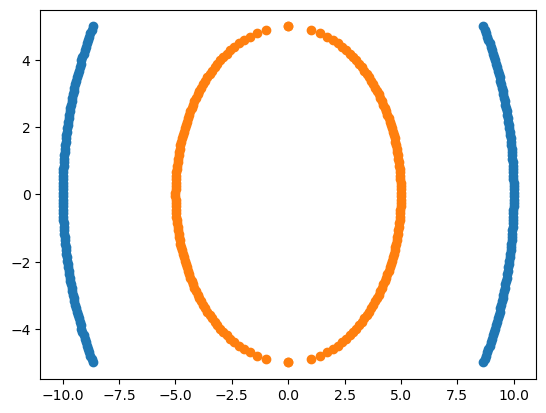

In [52]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [53]:
np.vstack([y,x])

array([[ 8.66025404,  8.71779204,  8.77378994,  8.82827705,  8.88128118,
         8.93282873,  8.98294476,  9.03165312,  9.07897646,  9.12493632,
         9.16955321,  9.21284664,  9.25483518,  9.29553652,  9.3349675 ,
         9.37314414,  9.41008171,  9.44579475,  9.4802971 ,  9.51360192,
         9.54572176,  9.57666854,  9.60645359,  9.63508769,  9.66258107,
         9.68894344,  9.714184  ,  9.73831149,  9.76133416,  9.7832598 ,
         9.80409577,  9.82384901,  9.84252604,  9.86013297,  9.87667553,
         9.89215905,  9.90658851,  9.91996849,  9.93230325,  9.94359667,
         9.9538523 ,  9.96307334,  9.97126266,  9.9784228 ,  9.98455598,
         9.98966408,  9.99374868,  9.99681104,  9.99885209,  9.99987246,
         9.99987246,  9.99885209,  9.99681104,  9.99374868,  9.98966408,
         9.98455598,  9.9784228 ,  9.97126266,  9.96307334,  9.9538523 ,
         9.94359667,  9.93230325,  9.91996849,  9.90658851,  9.89215905,
         9.87667553,  9.86013297,  9.84252604,  9.8

In [54]:
import pandas as pd
df1=pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df = pd.concat([df1, df2], ignore_index=True)
df.head(5)

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [55]:
df.tail()

,X1,X2,Y
395,-1.969049,-4.59596,1
396,-1.714198,-4.69697,1
397,-1.406908,-4.79798,1
398,-0.999949,-4.89899,1
399,-0.000000,-5.00000,1


In [56]:
##Independent and Dependent Feature
X=df.iloc[:, :2]
y=df.Y

In [57]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [58]:
##Spilt dataset into  train and test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

### Polynomial kernel
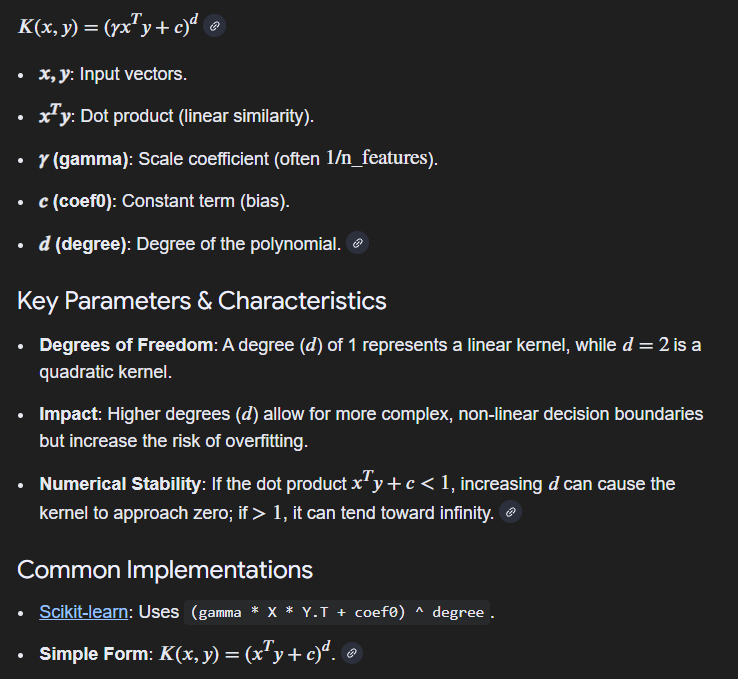

In [59]:
## We need to find components for the Polynomial Kernel
##X1,X2,X1_square,X2_square,X1*X2
df['X1_Square']=df['X1']**2
df['X2_Square']=df['X2']**2
df['X1*X2']=(df['X1']*df['X2'])
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [60]:
## Independent and Dependent Features
X=df[['X1','X2','X1_Square','X2_Square','X1*X2']]
y=df['Y']


In [61]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [62]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [63]:
X_train

,X1,X2,X1_Square,X2_Square,X1*X2
250,4.999745,0.050505,24.997449,0.002551,0.252512
63,9.906589,1.363636,98.140496,1.859504,13.508984
312,-3.263736,3.787879,10.651974,14.348026,-12.362637
159,-9.953852,-0.959596,99.079176,0.920824,9.551676
283,3.680983,3.383838,13.549638,11.450362,12.455852
...,...,...,...,...,...
323,-4.223140,2.676768,17.834915,7.165085,-11.304366
192,-9.031653,-4.292929,81.570758,18.429242,38.772248
117,-9.445795,3.282828,89.223038,10.776962,-31.008922
47,9.996811,-0.252525,99.936231,0.063769,-2.524447


In [64]:
import plotly.express as px

fig=px.scatter_3d(df,x='X1',y='X2',z='X1*X2',color='Y')
fig.show()

In [65]:
fig = px.scatter_3d(df, x='X1_Square', y='X1_Square', z='X1*X2',
              color='Y')
fig.show()

### Now we can easily classify data points and can make plane
#### Now use diff diff kernels to train the model

In [66]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [67]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="poly")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [68]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="rbf")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [69]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="sigmoid")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0